In [5]:
# Cell 2: End-to-End Point Generation & Complete Feature Extraction
import os
import pandas as pd
import numpy as np
import ee

# 1. Authenticate & Initialize GEE
ee.Authenticate()
ee.Initialize(project="sundarbans-ai")

# 2. Setup Exact Folder Paths
SAVE_DIR = '/content/drive/My Drive/GeoAI/GeoAI-Based Forest Fire Detection and Vegetation Stress Monitoring Using Multi-Source Remote Sensing Data/02_Data'
os.makedirs(SAVE_DIR, exist_ok=True)
final_output_csv = os.path.join(SAVE_DIR, 'Final_GeoAI_ML_Dataset.csv')

print("⏳ Step 1: Re-generating labeled points with exact Lat/Lon coordinates in memory...")

# 3. Load Study Area & Create 10km Buffer
sundarbans_core = ee.FeatureCollection("WCMC/WDPA/current/polygons").filter(
    ee.Filter.eq("NAME", "Sundarbans Reserved Forest")
)
study_area = sundarbans_core.geometry().buffer(10000)

# 4. Generate Fire & Non-Fire Points with Geometries
firms = ee.ImageCollection("FIRMS").filterBounds(study_area).filterDate("2012-01-01", "2024-01-01")
fire_mask = firms.select("T21").max().clip(study_area).gt(0)

fire_points = fire_mask.selfMask().sample(
    region=study_area, scale=500, numPixels=500, seed=42, geometries=True
).map(lambda f: f.set("fire_label", 1))

non_fire_points = fire_mask.unmask(0).eq(0).clip(study_area).selfMask().sample(
    region=study_area, scale=500, numPixels=800, seed=101, geometries=True
).map(lambda f: f.set("fire_label", 0))

points_fc = fire_points.merge(non_fire_points)
print("✅ Points generated successfully with spatial geometries!")

# 5. Build Sentinel-2 & DEM Feature Stack
print("⏳ Step 2: Processing Sentinel-2 Spectral Indices & SRTM DEM...")
def mask_s2_clouds(image):
    qa = image.select('QA60')
    mask = qa.bitwiseAnd(1 << 10).eq(0).And(qa.bitwiseAnd(1 << 11).eq(0))
    return image.updateMask(mask).divide(10000)

s2 = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
      .filterBounds(study_area)
      .filterDate("2018-01-01", "2023-12-31")
      .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 30))
      .map(mask_s2_clouds).median().clip(study_area))

ndvi = s2.normalizedDifference(['B8', 'B4']).rename('NDVI')
ndmi = s2.normalizedDifference(['B8', 'B11']).rename('NDMI')
nbr = s2.normalizedDifference(['B8', 'B12']).rename('NBR')
ndwi = s2.normalizedDifference(['B3', 'B8']).rename('NDWI')

srtm = ee.Image("USGS/SRTMGL1_003").clip(study_area)
elevation = srtm.select('elevation').rename('Elevation')
slope = ee.Terrain.slope(srtm).rename('Slope')

# Stack 12 predictor bands
feature_stack = s2.select(['B2', 'B3', 'B4', 'B8', 'B11', 'B12']).addBands(
    [ndvi, ndmi, nbr, ndwi, elevation, slope]
).unmask(0)

# 6. Extract Features & Coordinates
print("⏳ Step 3: Extracting all 12 predictor bands for each location... (Takes ~30 seconds)")
sampled = feature_stack.sampleRegions(
    collection=points_fc,
    properties=['fire_label'],
    scale=30,
    tileScale=4,
    geometries=True
)

# Convert Earth Engine features to structured Python Dictionary including Lat/Lon
features_list = sampled.getInfo()['features']
extracted_data = []

for f in features_list:
    row = f['properties']
    coords = f['geometry']['coordinates']
    row['longitude'] = coords[0]
    row['latitude'] = coords[1]
    extracted_data.append(row)

# 7. Save Final Clean Dataset to Drive
df_final = pd.DataFrame(extracted_data)
df_final.to_csv(final_output_csv, index=False)

print(f"\n🎉 SUCCESS! Extracted {len(df_final)} complete rows with Lat/Lon and all 12 feature bands.")
print(f"📁 Saved finalized dataset at:\n{final_output_csv}\n")

print("Preview of first 5 rows of your Machine Learning dataset:")
display(df_final.head())

⏳ Step 1: Re-generating labeled points with exact Lat/Lon coordinates in memory...
✅ Points generated successfully with spatial geometries!
⏳ Step 2: Processing Sentinel-2 Spectral Indices & SRTM DEM...
⏳ Step 3: Extracting all 12 predictor bands for each location... (Takes ~30 seconds)

🎉 SUCCESS! Extracted 803 complete rows with Lat/Lon and all 12 feature bands.
📁 Saved finalized dataset at:
/content/drive/My Drive/GeoAI/GeoAI-Based Forest Fire Detection and Vegetation Stress Monitoring Using Multi-Source Remote Sensing Data/02_Data/Final_GeoAI_ML_Dataset.csv

Preview of first 5 rows of your Machine Learning dataset:


,B11,B12,B2,B3,B4,B8,Elevation,NBR,NDMI,NDVI,NDWI,Slope,fire_label,longitude,latitude
0,0.060315,0.029582,0.050889,0.074093,0.058611,0.183923,5,0.722890,0.506096,0.516677,-0.425674,4.404421,1,88.988325,22.106237
1,0.030600,0.020200,0.110450,0.126025,0.118100,0.069450,0,0.549359,0.388306,-0.259398,0.289423,0.000000,1,89.445927,21.714661
2,0.013833,0.009663,0.091680,0.107595,0.103274,0.048725,0,0.669005,0.557746,-0.358878,0.376600,0.000000,1,89.154064,22.075245
3,0.013884,0.010620,0.091954,0.107547,0.107337,0.052955,0,0.665897,0.584546,-0.339274,0.340137,0.000000,1,88.984821,22.104889
4,0.013861,0.010781,0.091855,0.111429,0.100329,0.040775,0,0.581767,0.492609,-0.422056,0.464207,0.000000,0,89.264557,21.593388


Interactive 3D Feature Space Plot

In [6]:
# Cell 3: Interactive 3D Scatter Plot for Feature Space Analysis
import plotly.express as px

# Convert fire_label to string for discrete color mapping (0 = Green, 1 = Red)
df_final['Fire_Status'] = df_final['fire_label'].map({0: 'Non-Fire (Healthy/Safe)', 1: 'Fire Point (Burned/Risk)'})

# Create a premium 3D scatter plot
fig = px.scatter_3d(
    df_final,
    x='NDVI',
    y='NDMI',
    z='Elevation',
    color='Fire_Status',
    color_discrete_map={
        'Non-Fire (Healthy/Safe)': '#2ec4b6',  # Teal/Greenish
        'Fire Point (Burned/Risk)': '#e71d36'   # Bright Red
    },
    title='3D Multi-Source Feature Space: NDVI vs NDMI vs Elevation',
    labels={'NDVI': 'NDVI (Vegetation Health)', 'NDMI': 'NDMI (Moisture Stress)', 'Elevation': 'Elevation (m)'},
    opacity=0.8
)

# Customize the 3D environment layout for high visual appeal
fig.update_layout(
    template='plotly_white',
    scene=dict(
        xaxis=dict(backgroundcolor="rgba(0, 0, 0, 0)", gridcolor="lightgray", showbackground=True),
        yaxis=dict(backgroundcolor="rgba(0, 0, 0, 0)", gridcolor="lightgray", showbackground=True),
        zaxis=dict(backgroundcolor="rgba(0, 0, 0, 0)", gridcolor="lightgray", showbackground=True)
    ),
    margin=dict(l=0, r=0, b=0, t=50),
    legend=dict(title_text='Class Labels', yanchor="top", y=0.99, xanchor="left", x=0.01)
)

fig.show()

In [7]:
# Cell 3 (Revised): Publication-Ready 3D Feature Space for Research Paper
import plotly.express as px
import pandas as pd

# Sort dataframe so Fire points (1) are plotted ON TOP of Non-Fire points (0)
df_sorted = df_final.sort_values(by='fire_label', ascending=True)
df_sorted['Fire_Status'] = df_sorted['fire_label'].map({0: 'Non-Fire (Safe Zone)', 1: 'Fire Point (High Risk)'})

# Assign custom sizes: Fire points larger (6), Non-Fire smaller (3)
df_sorted['Marker_Size'] = df_sorted['fire_label'].map({0: 3.5, 1: 6.5})

fig = px.scatter_3d(
    df_sorted,
    x='NDVI',
    y='NDMI',
    z='Elevation',
    color='Fire_Status',
    size='Marker_Size',
    size_max=8,
    color_discrete_map={
        'Non-Fire (Safe Zone)': '#2ec4b6',  # Teal
        'Fire Point (High Risk)': '#e71d36'  # Bright Red
    },
    title='<b>Figure 1: 3D Feature Space Distribution (NDVI vs NDMI vs Elevation)</b>',
    labels={'NDVI': 'NDVI (Vegetation Health)', 'NDMI': 'NDMI (Moisture Stress)', 'Elevation': 'Elevation (m)'},
    opacity=0.85
)

# Set Default Fixed Camera Angle for Perfect Screenshot
camera_angle = dict(
    eye=dict(x=1.5, y=-1.5, z=0.8)  # Optimal viewing angle for paper export
)

fig.update_layout(
    template='plotly_white',
    scene=dict(
        camera=camera_angle,
        xaxis=dict(title='<b>NDVI</b>', backgroundcolor="white", gridcolor="#E5E5E5", showbackground=True),
        yaxis=dict(title='<b>NDMI</b>', backgroundcolor="white", gridcolor="#E5E5E5", showbackground=True),
        zaxis=dict(title='<b>Elevation (m)</b>', backgroundcolor="white", gridcolor="#E5E5E5", showbackground=True)
    ),
    margin=dict(l=10, r=10, b=10, t=60),
    legend=dict(title=dict(text='<b>Class Labels</b>'), yanchor="top", y=0.95, xanchor="left", x=0.02, bgcolor="rgba(255,255,255,0.8)", bordercolor="gray", borderwidth=1)
)

fig.show()

High-Resolution (300 DPI) Publication Figure saved at:
/content/drive/My Drive/GeoAI/GeoAI-Based Forest Fire Detection and Vegetation Stress Monitoring Using Multi-Source Remote Sensing Data/02_Data/Figure_2D_Feature_Projections_300DPI.png



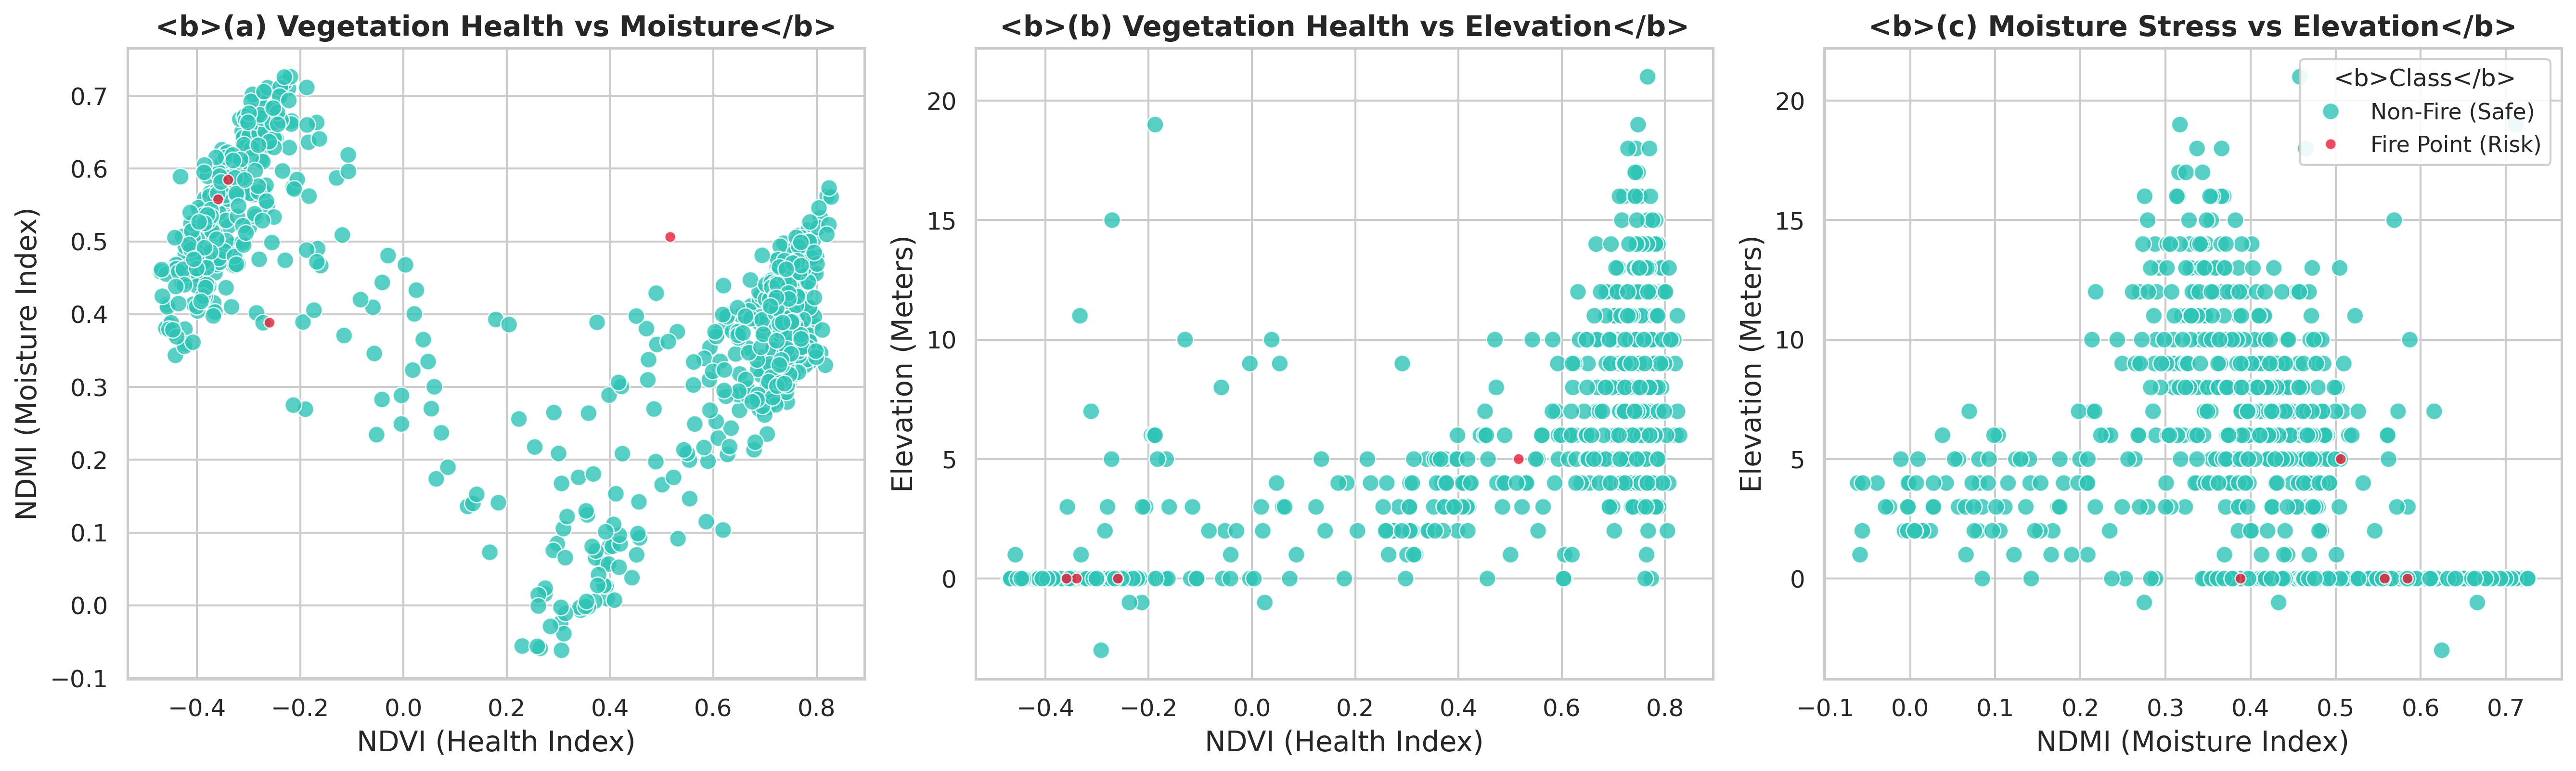

In [8]:
# Cell 4: Publication-Grade 2D Multi-Feature Projections (High-DPI Static Plot)
import matplotlib.pyplot as plt
import seaborn as sns

# Set publication style
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.titlesize': 16
})

# Create a 1x3 Grid for Pairwise Feature Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), dpi=300)

palette = {0: '#2ec4b6', 1: '#e71d36'}
labels = {0: 'Non-Fire (Safe)', 1: 'Fire (Risk)'}

# Plot 1: NDVI vs NDMI
sns.scatterplot(data=df_sorted, x='NDVI', y='NDMI', hue='fire_label', palette=palette,
                size='fire_label', sizes=(30, 70), alpha=0.8, ax=axes[0], legend=False)
axes[0].set_title('<b>(a) Vegetation Health vs Moisture</b>', fontweight='bold')
axes[0].set_xlabel('NDVI (Health Index)')
axes[0].set_ylabel('NDMI (Moisture Index)')

# Plot 2: NDVI vs Elevation
sns.scatterplot(data=df_sorted, x='NDVI', y='Elevation', hue='fire_label', palette=palette,
                size='fire_label', sizes=(30, 70), alpha=0.8, ax=axes[1], legend=False)
axes[1].set_title('<b>(b) Vegetation Health vs Elevation</b>', fontweight='bold')
axes[1].set_xlabel('NDVI (Health Index)')
axes[1].set_ylabel('Elevation (Meters)')

# Plot 3: NDMI vs Elevation
sns.scatterplot(data=df_sorted, x='NDMI', y='Elevation', hue='fire_label', palette=palette,
                size='fire_label', sizes=(30, 70), alpha=0.8, ax=axes[2])
axes[2].set_title('<b>(c) Moisture Stress vs Elevation</b>', fontweight='bold')
axes[2].set_xlabel('NDMI (Moisture Index)')
axes[2].set_ylabel('Elevation (Meters)')

# Customizing Legend for the entire figure
handles, _ = axes[2].get_legend_handles_labels()
axes[2].legend(handles=handles[:2], labels=['Non-Fire (Safe)', 'Fire Point (Risk)'],
               title='<b>Class</b>', loc='upper right', frameon=True, facecolor='white', framealpha=0.9)

plt.tight_layout()

# Save publication-ready high-resolution image directly to Drive
save_img_path = os.path.join(SAVE_DIR, 'Figure_2D_Feature_Projections_300DPI.png')
plt.savefig(save_img_path, dpi=300, bbox_inches='tight')
print(f"High-Resolution (300 DPI) Publication Figure saved at:\n{save_img_path}\n")

plt.show()

Publication-Grade Correlation Heatmap

Correlation Heatmap (300 DPI) saved successfully at:
/content/drive/My Drive/GeoAI/GeoAI-Based Forest Fire Detection and Vegetation Stress Monitoring Using Multi-Source Remote Sensing Data/02_Data/Figure_Correlation_Heatmap_300DPI.png



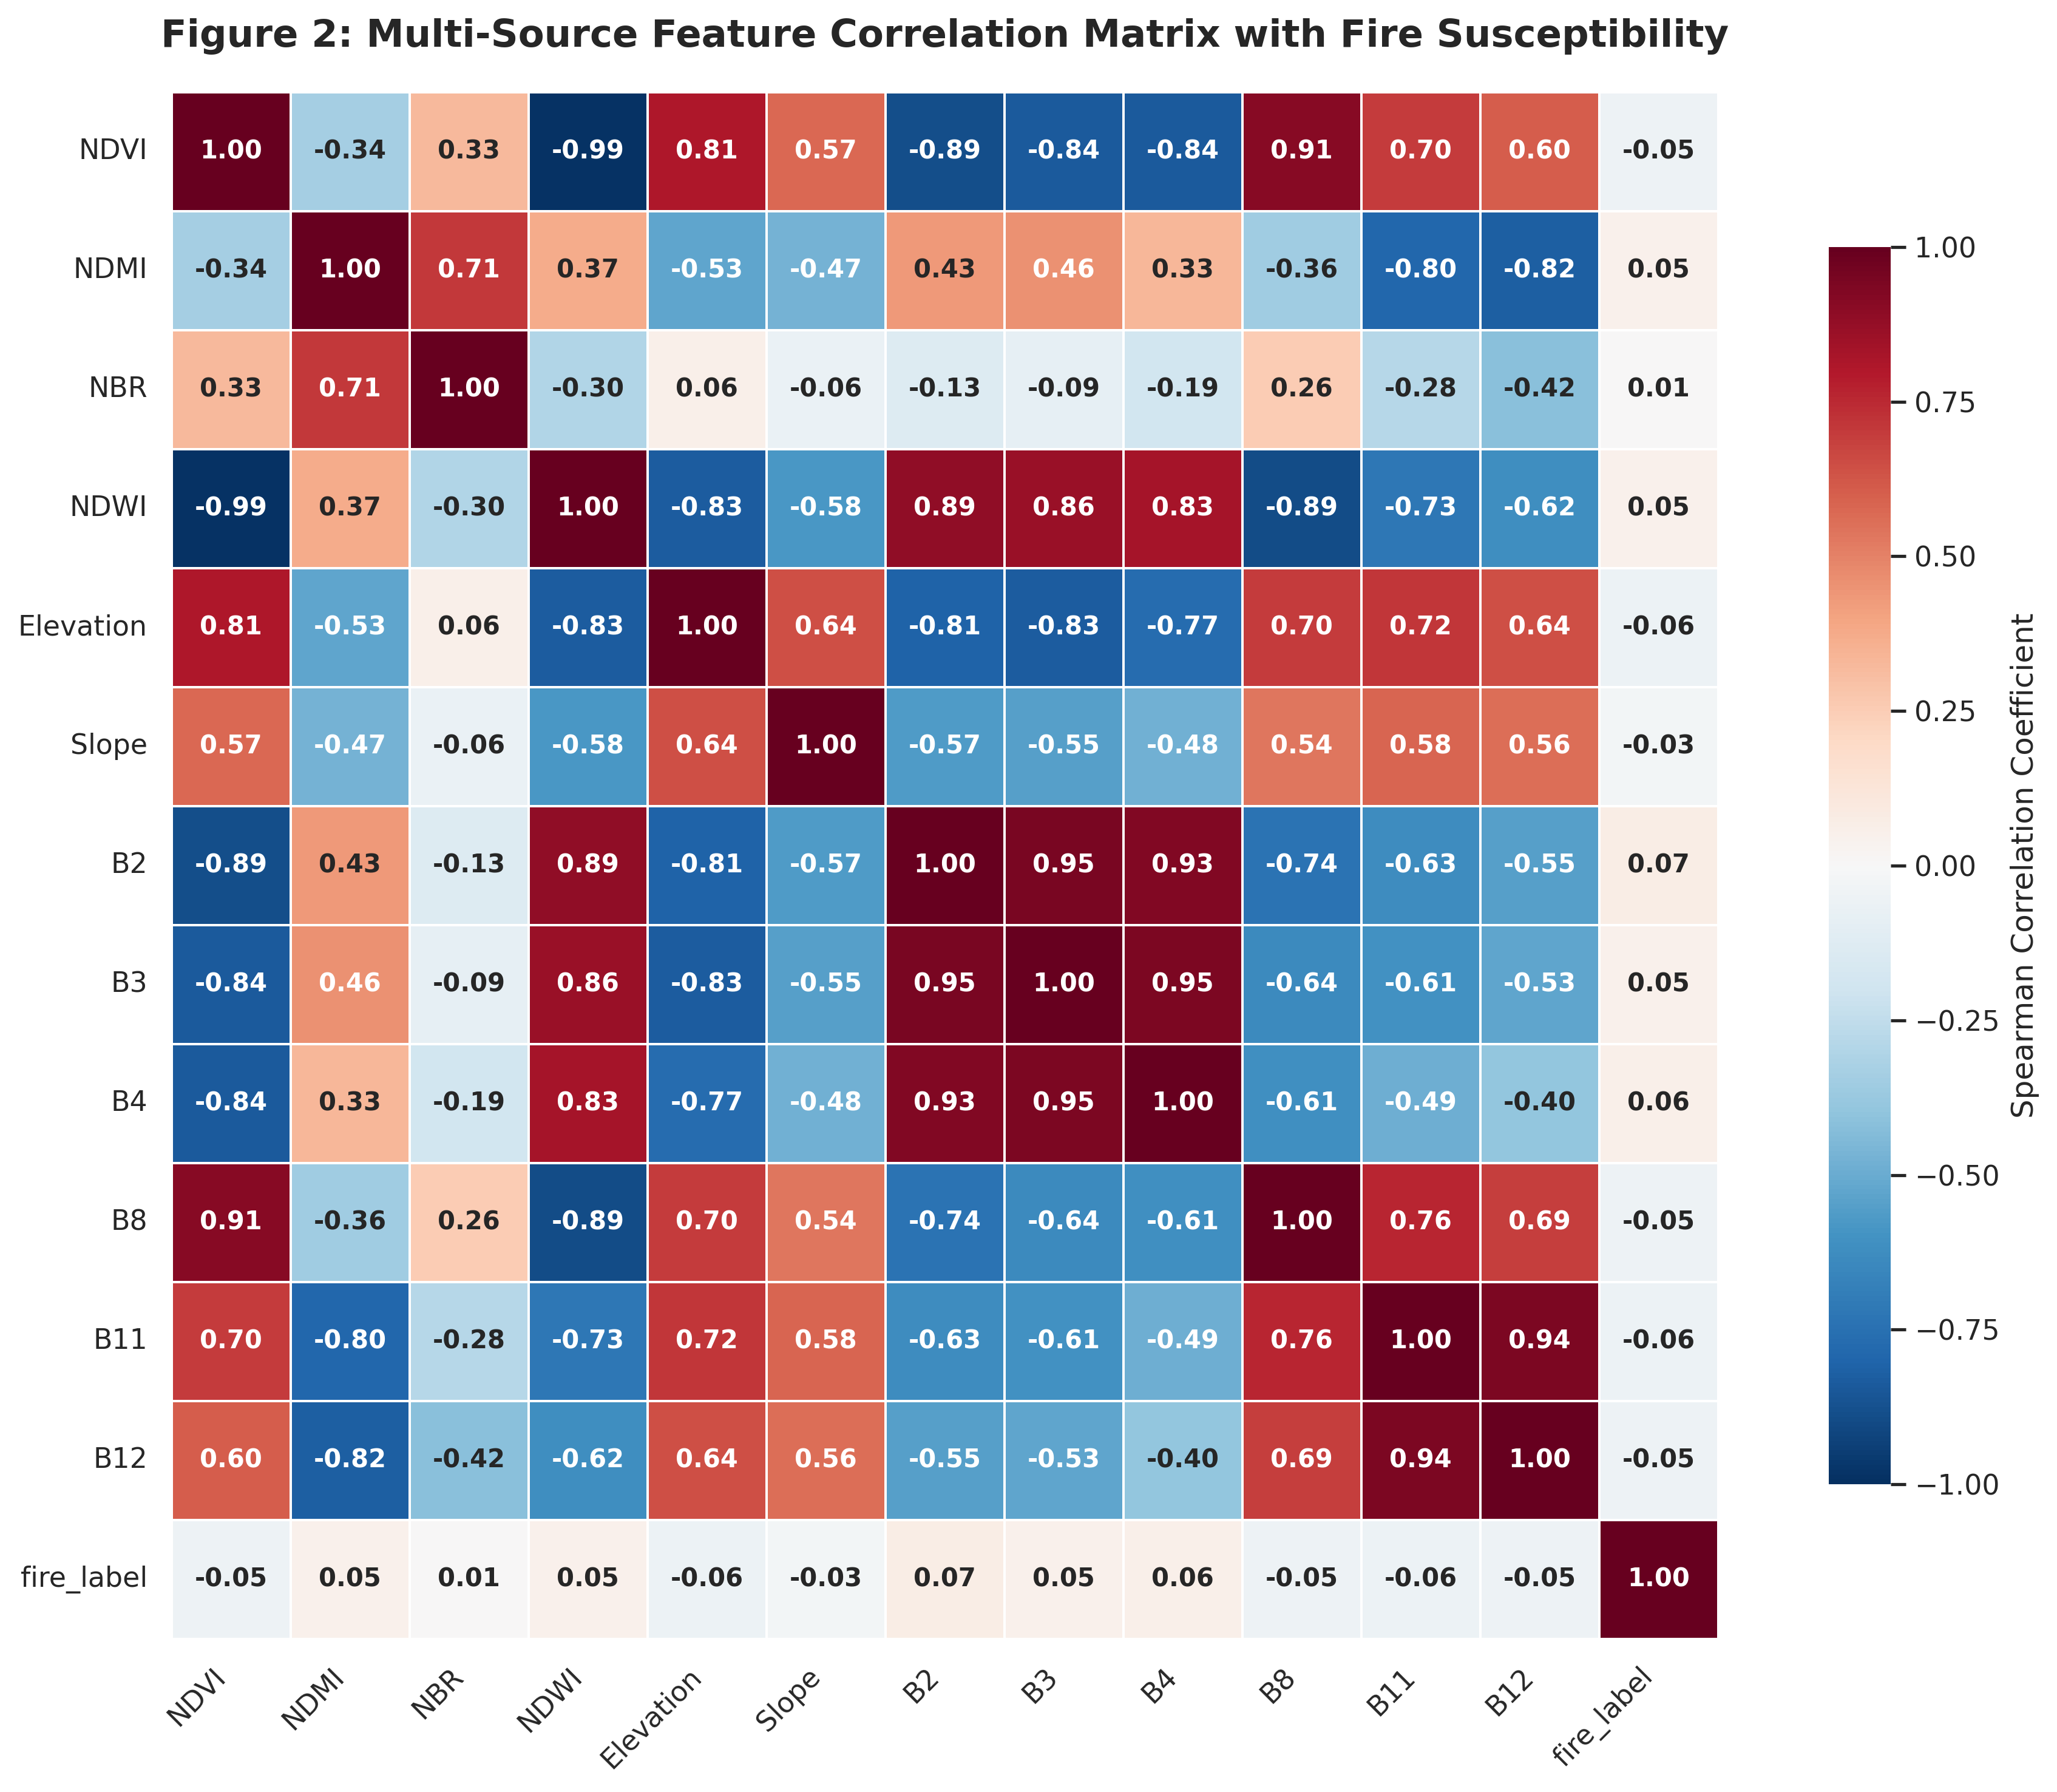

In [9]:
# Cell 5: Publication-Grade Correlation Heatmap (300 DPI)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Select only numerical predictor columns + target label for correlation
columns_to_correlate = [
    'NDVI', 'NDMI', 'NBR', 'NDWI',
    'Elevation', 'Slope',
    'B2', 'B3', 'B4', 'B8', 'B11', 'B12',
    'fire_label'
]

# Calculate Spearman correlation (best for non-linear remote sensing features)
corr_matrix = df_final[columns_to_correlate].corr(method='spearman')

# 2. Setup Figure for High-DPI Paper Export
plt.figure(figsize=(13, 10), dpi=300)
sns.set_theme(style="white")

# Create a customized heatmap
heatmap = sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1, vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Spearman Correlation Coefficient"},
    annot_kws={"size": 10, "weight": "bold"}
)

# Set clean titles without HTML tags for Matplotlib
plt.title("Figure 2: Multi-Source Feature Correlation Matrix with Fire Susceptibility",
          fontsize=15, fontweight='bold', pad=18)
plt.xticks(rotation=45, ha='right', fontsize=11, fontweight='medium')
plt.yticks(rotation=0, fontsize=11, fontweight='medium')

plt.tight_layout()

# Save publication-ready heatmap directly to Drive
heatmap_save_path = os.path.join(SAVE_DIR, 'Figure_Correlation_Heatmap_300DPI.png')
plt.savefig(heatmap_save_path, dpi=300, bbox_inches='tight')
print(f"Correlation Heatmap (300 DPI) saved successfully at:\n{heatmap_save_path}\n")

plt.show()

Data Preprocessing & Train-Test Split

In [10]:
# Cell 6: Data Preprocessing, Feature Scaling & Stratified Train-Test Split
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Define Features (X) and Target Label (y)
feature_columns = ['NDVI', 'NDMI', 'NBR', 'NDWI', 'Elevation', 'Slope', 'B2', 'B3', 'B4', 'B8', 'B11', 'B12']
X = df_final[feature_columns]
y = df_final['fire_label']

print(f"Features shape: {X.shape}, Target shape: {y.shape}")

# 2. Perform 80/20 Train-Test Split with Stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"\nTraining Set Size: {X_train.shape[0]} samples (80%)")
print(f"Testing Set Size: {X_test.shape[0]} samples (20%)")

# 3. Feature Scaling using StandardScaler (fit only on train data to prevent data leakage)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_columns, index=X_test.index)

# 4. Save Processed Datasets directly to Google Drive Project Folder
SAVE_DIR = '/content/drive/My Drive/GeoAI/GeoAI-Based Forest Fire Detection and Vegetation Stress Monitoring Using Multi-Source Remote Sensing Data/02_Data'

X_train_scaled.to_csv(os.path.join(SAVE_DIR, 'X_train_scaled.csv'), index=False)
X_test_scaled.to_csv(os.path.join(SAVE_DIR, 'X_test_scaled.csv'), index=False)
y_train.to_csv(os.path.join(SAVE_DIR, 'y_train.csv'), index=False)
y_test.to_csv(os.path.join(SAVE_DIR, 'y_test.csv'), index=False)

print(f"\n🎉 SUCCESS! All preprocessed datasets (X_train, X_test, y_train, y_test) securely saved inside:\n{SAVE_DIR}")
print("\nPreview of Scaled Training Features (First 5 rows):")
display(X_train_scaled.head())

Features shape: (803, 12), Target shape: (803,)

Training Set Size: 642 samples (80%)
Testing Set Size: 161 samples (20%)

🎉 SUCCESS! All preprocessed datasets (X_train, X_test, y_train, y_test) securely saved inside:
/content/drive/My Drive/GeoAI/GeoAI-Based Forest Fire Detection and Vegetation Stress Monitoring Using Multi-Source Remote Sensing Data/02_Data

Preview of Scaled Training Features (First 5 rows):


,NDVI,NDMI,NBR,NDWI,Elevation,Slope,B2,B3,B4,B8,B11,B12
404,-1.403647,0.722761,0.173088,1.441589,-1.022953,-0.817788,1.239914,1.152213,0.906862,-1.317021,-1.108131,-0.882626
148,0.819888,-1.063571,-0.418068,-0.841569,1.476518,-0.011850,-0.984193,-1.097720,-0.879425,0.499703,0.800830,0.484562
262,0.662118,-0.836084,-0.412149,-0.669852,0.851650,-0.270286,-0.603768,-0.618165,-0.532948,0.445839,0.604133,0.442336
676,0.962200,-0.454967,0.426714,-0.951762,1.059939,-0.012347,-1.120882,-1.228381,-1.093970,0.762188,0.622379,0.113350
345,0.972055,0.295672,0.689171,-0.909403,-0.189796,-0.817788,-0.899759,-0.815495,-0.978248,1.125362,0.383868,0.110346


Calculating Variance Inflation Factor (VIF) for all predictor features...
 VIF Table saved successfully at:
/content/drive/My Drive/GeoAI/GeoAI-Based Forest Fire Detection and Vegetation Stress Monitoring Using Multi-Source Remote Sensing Data/02_Data/Table_Feature_VIF_Scores.csv

Multicollinearity VIF Results (Generally VIF > 10 indicates high correlation):


,Feature,VIF_Score
0,NDVI,13814.451371
1,NDWI,12512.730625
2,B3,7939.134475
3,B4,5713.827966
4,NBR,904.938064
5,B11,719.308214
6,B2,695.451720
7,NDMI,461.350932
8,B12,453.558581
9,B8,437.579982



 High-Resolution Scaling Comparison Boxplot saved at:
/content/drive/My Drive/GeoAI/GeoAI-Based Forest Fire Detection and Vegetation Stress Monitoring Using Multi-Source Remote Sensing Data/02_Data/Figure_Before_After_Scaling_Boxplot_300DPI.png



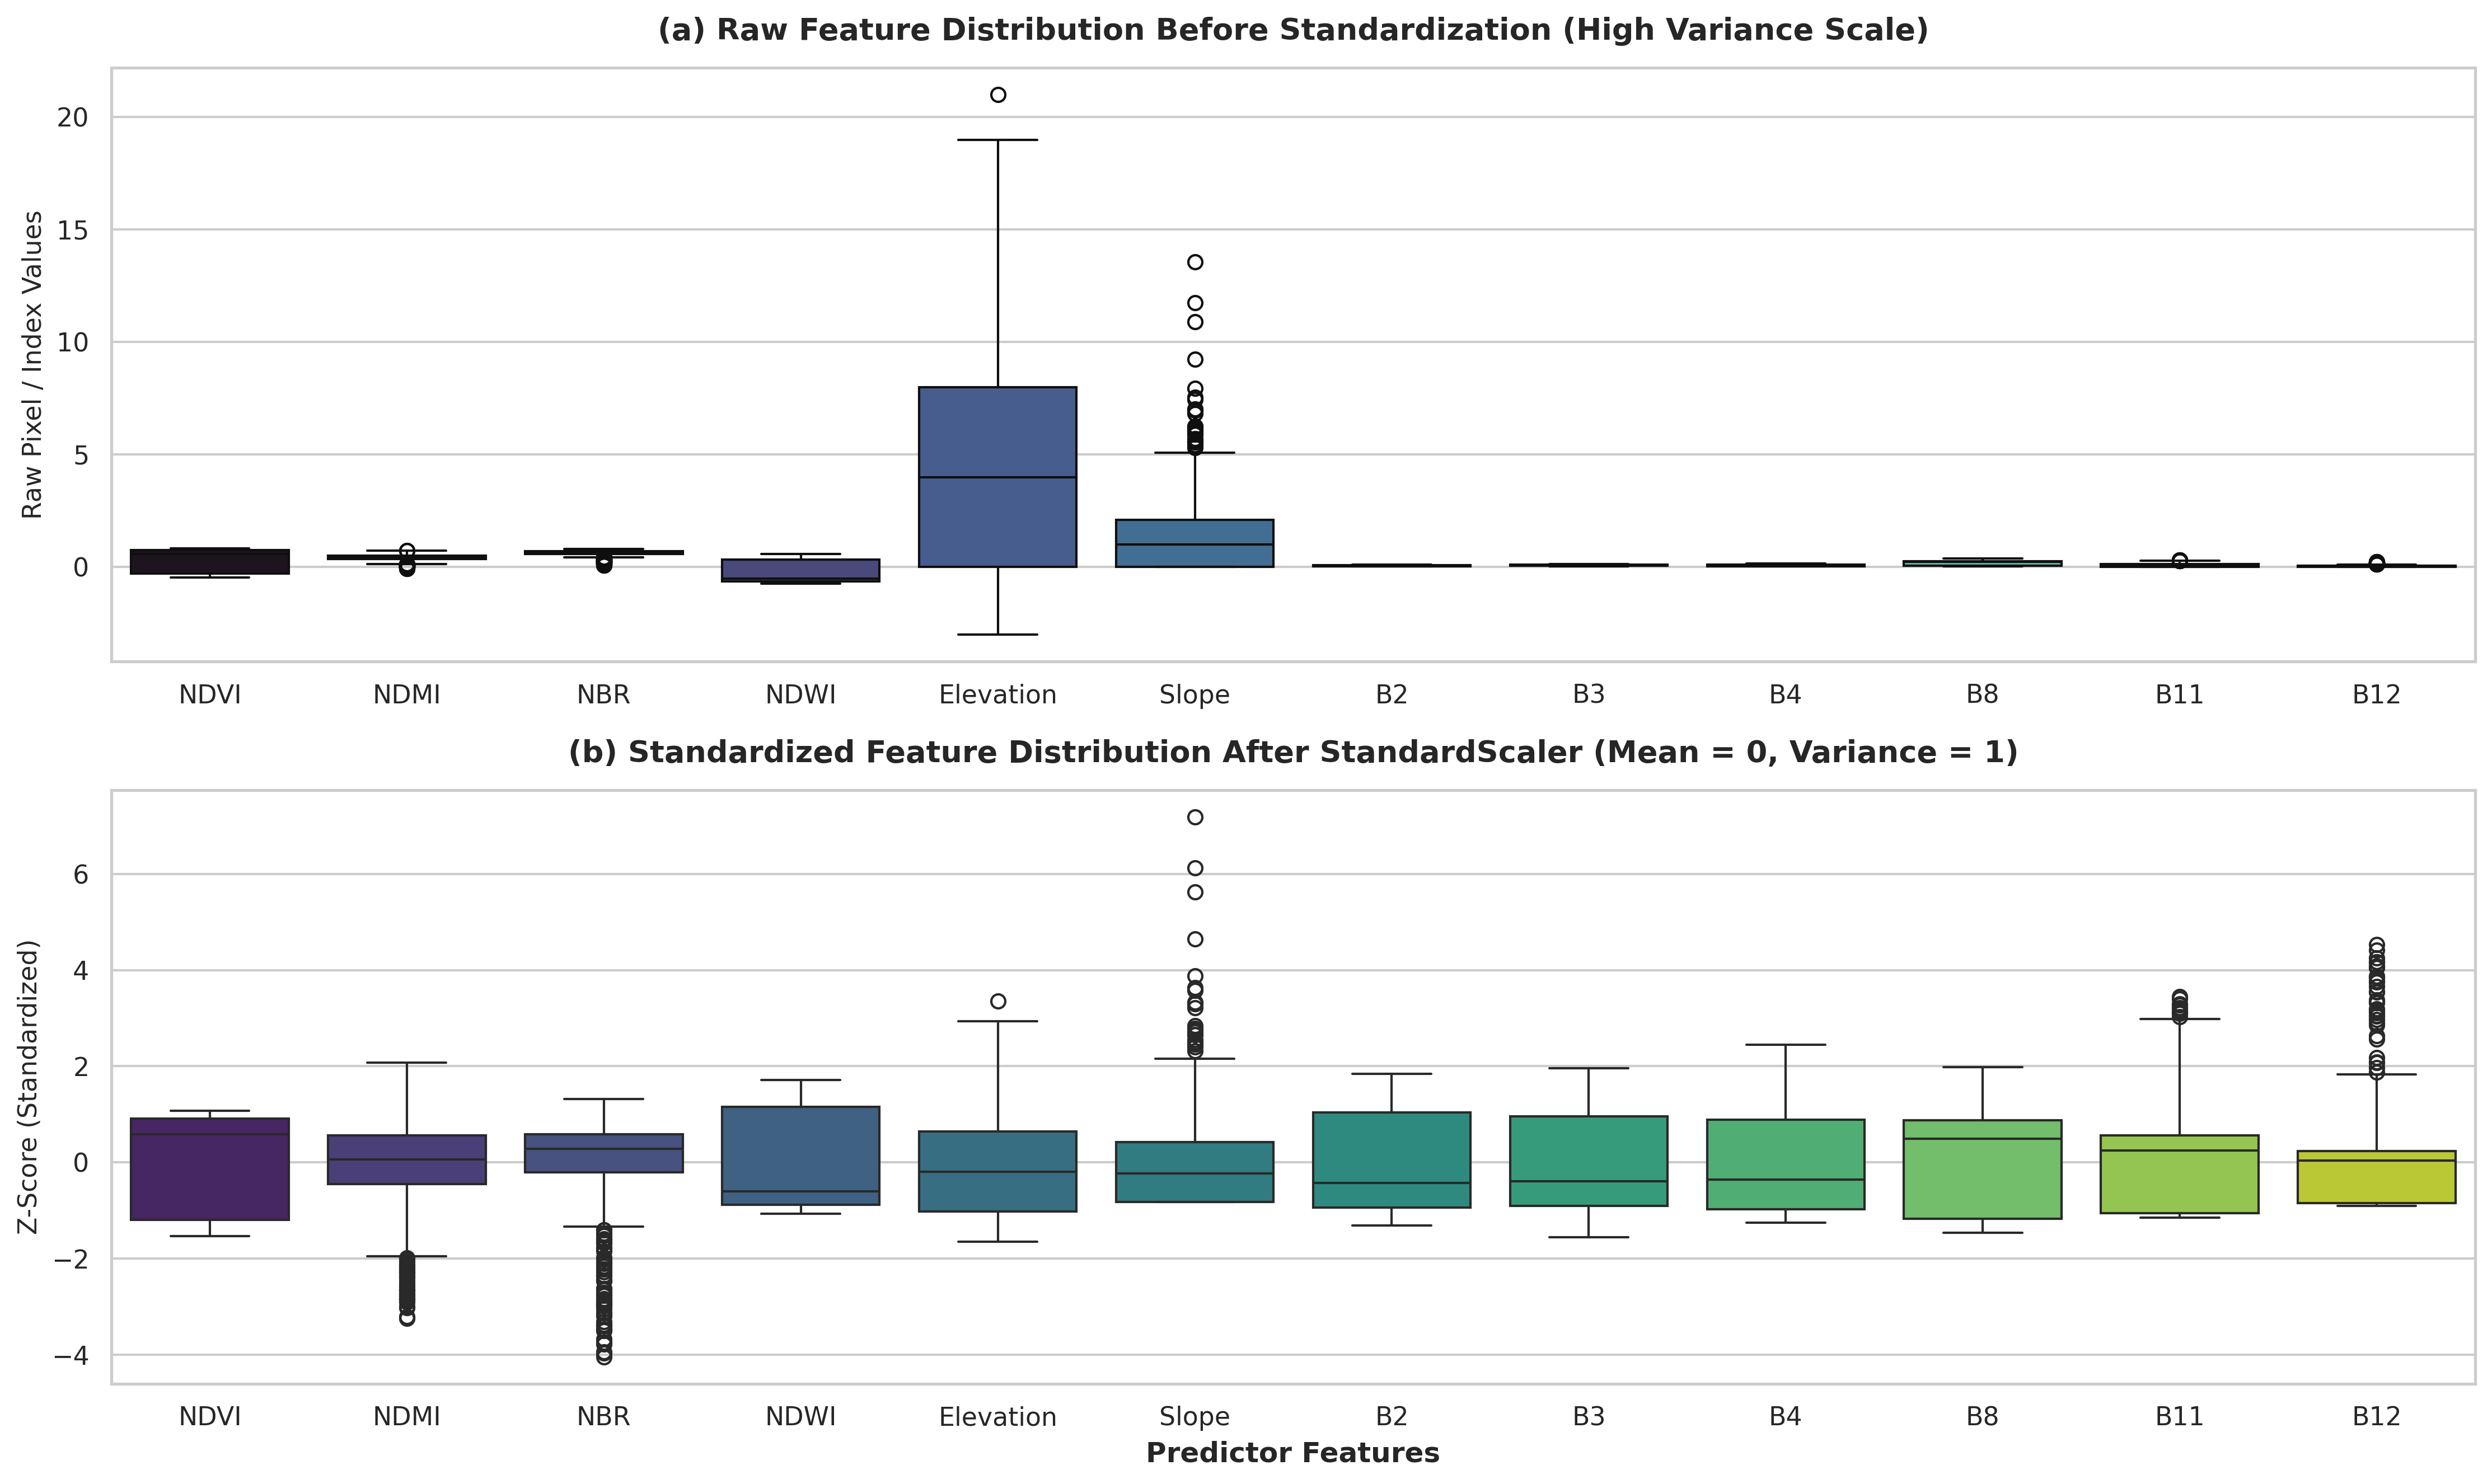

In [11]:
# Cell 7: Research Paper Enrichment - VIF Analysis and Before vs. After Scaling Boxplot
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Calculate VIF (Variance Inflation Factor) to check Multicollinearity
print("Calculating Variance Inflation Factor (VIF) for all predictor features...")
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF_Score"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values(by="VIF_Score", ascending=False).reset_index(drop=True)

# Save VIF table to Drive
vif_csv_path = os.path.join(SAVE_DIR, 'Table_Feature_VIF_Scores.csv')
vif_data.to_csv(vif_csv_path, index=False)
print(f" VIF Table saved successfully at:\n{vif_csv_path}\n")

print("Multicollinearity VIF Results (Generally VIF > 10 indicates high correlation):")
display(vif_data)

# 2. Setup Publication-Grade Figure for Before vs. After Scaling
plt.figure(figsize=(15, 9), dpi=300)
sns.set_theme(style="whitegrid")

# Subplot 1: Raw Unscaled Features
plt.subplot(2, 1, 1)
sns.boxplot(data=X, palette="mako")
plt.title("(a) Raw Feature Distribution Before Standardization (High Variance Scale)",
          fontsize=13, fontweight='bold', pad=12)
plt.ylabel("Raw Pixel / Index Values", fontsize=11)
plt.xticks(rotation=0)

# Subplot 2: Standardized Features
plt.subplot(2, 1, 2)
sns.boxplot(data=X_train_scaled, palette="viridis")
plt.title("(b) Standardized Feature Distribution After StandardScaler (Mean = 0, Variance = 1)",
          fontsize=13, fontweight='bold', pad=12)
plt.ylabel("Z-Score (Standardized)", fontsize=11)
plt.xlabel("Predictor Features", fontsize=12, fontweight='bold')
plt.xticks(rotation=0)

plt.tight_layout()

# Save Boxplot image directly to Google Drive
boxplot_save_path = os.path.join(SAVE_DIR, 'Figure_Before_After_Scaling_Boxplot_300DPI.png')
plt.savefig(boxplot_save_path, dpi=300, bbox_inches='tight')
print(f"\n High-Resolution Scaling Comparison Boxplot saved at:\n{boxplot_save_path}\n")

plt.show()